# 03 — Bayesian Analysis
Bimodal prior training, latent sampling with/without context, and category histogram analysis.

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import neuromorph
os.chdir(os.path.dirname(os.path.dirname(neuromorph.__file__)))
print(f"Working directory: {os.getcwd()}")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from neuromorph.configs import ExperimentConfig
from neuromorph.training import set_global_seed
from neuromorph.data import get_mnist_dataloaders, generate_context, add_noise
from neuromorph.models import Autoencoder, MNISTClassifier, freeze_except_context
from neuromorph.analysis.bayesian import (
    compute_digit_centroids, compute_similarity_order, run_corruption_test,
    compute_basin_proportions, compute_sigmoid_data, fit_sigmoid,
    compute_nonparametric_bayesian,
    compute_centroid_rdm, run_pair_analysis,
)
from neuromorph.visualization import apply_neuromorph_style, save_figure
from neuromorph.visualization.bayesian import (
    plot_category_histogram, plot_sample_images, plot_basin_analysis,
    plot_bayesian_sigmoid, plot_centroid_rdm, plot_all_pairs_summary,
    plot_all_pairs_sigmoid_mosaic, plot_np_bayesian_summary, plot_average_sigmoid_v2,
)

apply_neuromorph_style()

config = ExperimentConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

set_global_seed(config.training.seed)

## Load Data

In [2]:
train_dl, test_dl = get_mnist_dataloaders(batch_size=config.training.batch_size)

## Train 10-Class MNIST Classifier
A simple CNN classifier trained on clean MNIST, used to label decoded samples.

In [3]:
classifier_path = os.path.join(config.pretrained_dir, 'mnist_classifier.pth')
config.ensure_dirs()

classifier = MNISTClassifier().to(device)

if os.path.isfile(classifier_path):
    classifier.load_state_dict(torch.load(classifier_path, map_location=device, weights_only=True))
    print("Loaded pretrained classifier.")
else:
    optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    classifier.train()
    for epoch in range(10):
        total_loss = 0
        for images, labels in train_dl:
            images, labels = images.to(device), labels.to(device)
            logits = classifier(images)
            loss = F.cross_entropy(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/10, Loss: {total_loss/len(train_dl):.4f}")
    torch.save(classifier.state_dict(), classifier_path)
    print(f"Classifier saved to {classifier_path}")

# Evaluate
classifier.eval()
correct, total = 0, 0
for images, labels in test_dl:
    images, labels = images.to(device), labels.to(device)
    preds = classifier.predict(images)
    correct += (preds == labels).sum().item()
    total += labels.size(0)
print(f"Classifier accuracy: {correct/total:.4f}")

Loaded pretrained classifier.
Classifier accuracy: 0.9914


## Experiment 1: Two-Channel Context (Control)
Each digit gets its own context channel. Verifies the model *can* learn selective associations.

## Experiment 2: Single-Channel Probabilistic Context (Key Test)
One context signal paired 50% with digit_a and 50% with digit_b.
**Key question**: does a single ambiguous context induce a *bimodal* prior (two peaks) or a *blurred average*?

In [4]:
mc = config.model
nc = config.noise
bc = config.bimodal

bimodal_path = os.path.join(config.pretrained_dir, 'bimodal_deep_autoencoder.pth')
baseline_path = os.path.join(config.pretrained_dir, 'baseline_deep_autoencoder.pth')

# Use different context channels for each digit
CONTEXT_ID_A = 2  # context channel for digit_a
CONTEXT_ID_B = 3  # context channel for digit_b

# Start from baseline
bimodal_ae = Autoencoder(mc.capacity, mc.latent_dims, mc.context_dim).to(device)
bimodal_ae.load_state_dict(torch.load(baseline_path, map_location=device, weights_only=True))

if os.path.isfile(bimodal_path):
    bimodal_ae.load_state_dict(torch.load(bimodal_path, map_location=device, weights_only=True))
    print("Loaded pretrained bimodal model.")
else:
    freeze_except_context(bimodal_ae)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, bimodal_ae.parameters()), lr=config.training.lr)

    print(f"Bimodal association training: context[{CONTEXT_ID_A}] -> digit {bc.digit_a}, context[{CONTEXT_ID_B}] -> digit {bc.digit_b}")
    for epoch in range(bc.epochs_association):
        total_loss = 0
        for image_batch, label_batch in train_dl:
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)

            context_batch = generate_context(
                image_batch.size(0), signal_level=None,
                noise_level=bc.noise_level, category_id=0,
                context_dim=mc.context_dim, device=device
            )

            idx_a = (label_batch == bc.digit_a).nonzero(as_tuple=True)[0]
            if len(idx_a) > 0:
                context_batch[idx_a] = generate_context(
                    len(idx_a), signal_level=bc.signal_level,
                    noise_level=bc.noise_level, category_id=CONTEXT_ID_A,
                    context_dim=mc.context_dim, device=device
                )

            idx_b = (label_batch == bc.digit_b).nonzero(as_tuple=True)[0]
            if len(idx_b) > 0:
                context_batch[idx_b] = generate_context(
                    len(idx_b), signal_level=bc.signal_level,
                    noise_level=bc.noise_level, category_id=CONTEXT_ID_B,
                    context_dim=mc.context_dim, device=device
                )

            noisy_batch = add_noise(
                image_batch, noise_level=nc.training_noise_level,
                correlated=nc.correlated, uncorrelated=nc.uncorrelated,
                kernel_size=nc.kernel_size, sigma=nc.sigma
            )
            reconstructed = bimodal_ae(noisy_batch, context_batch)
            loss = F.mse_loss(reconstructed, image_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_dl)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{bc.epochs_association}, Loss: {avg_loss:.6f}")

    torch.save(bimodal_ae.state_dict(), bimodal_path)
    print(f"Bimodal model saved to {bimodal_path}")

bimodal_ae.eval()
print("Bimodal model ready.")

Loaded pretrained bimodal model.
Bimodal model ready.


## Noise Corruption Test
Feed heavily corrupted test images through the autoencoder with/without context.
Classify the reconstructions and build category histograms.
This is the same approach as notebooks 01-02 but with extreme noise — approximating the "in the dark" condition.

In [5]:
EXTREME_NOISE = 1.0  # double the training noise (0.5) — heavily degraded but reconstructable

# --- Exp 1: Two-channel context ---
hist_no_ctx = np.zeros(10)
hist_ctx_a = np.zeros(10)
hist_ctx_b = np.zeros(10)
n_total = 0
exp1_samples = {}

bimodal_ae.eval()
classifier.eval()

with torch.no_grad():
    for images, labels in test_dl:
        images = images.to(device)
        bs = images.size(0)

        noisy = add_noise(images, noise_level=EXTREME_NOISE,
                          correlated=nc.correlated, uncorrelated=nc.uncorrelated,
                          kernel_size=nc.kernel_size, sigma=nc.sigma)

        no_ctx = generate_context(bs, signal_level=None,
                                  noise_level=bc.noise_level, category_id=0,
                                  context_dim=mc.context_dim, device=device)
        ctx_a = generate_context(bs, signal_level=config.context.eval_signal_level,
                                 noise_level=bc.noise_level, category_id=CONTEXT_ID_A,
                                 context_dim=mc.context_dim, device=device)
        ctx_b = generate_context(bs, signal_level=config.context.eval_signal_level,
                                 noise_level=bc.noise_level, category_id=CONTEXT_ID_B,
                                 context_dim=mc.context_dim, device=device)

        recon_none = bimodal_ae(noisy, no_ctx)
        recon_a = bimodal_ae(noisy, ctx_a)
        recon_b = bimodal_ae(noisy, ctx_b)

        hist_no_ctx += np.bincount(classifier.predict(recon_none).cpu().numpy(), minlength=10)
        hist_ctx_a += np.bincount(classifier.predict(recon_a).cpu().numpy(), minlength=10)
        hist_ctx_b += np.bincount(classifier.predict(recon_b).cpu().numpy(), minlength=10)
        n_total += bs

        if not exp1_samples:
            exp1_samples = {
                'original': images[:10].cpu(),
                'noisy': noisy[:10].cpu(),
                'recon_no_ctx': recon_none[:10].cpu(),
                'recon_ctx_a': recon_a[:10].cpu(),
                'recon_ctx_b': recon_b[:10].cpu(),
            }

hist_no_ctx /= n_total
hist_ctx_a /= n_total
hist_ctx_b /= n_total

print("No context:  ", np.round(hist_no_ctx, 3))
print(f"Context A ({bc.digit_a}): ", np.round(hist_ctx_a, 3))
print(f"Context B ({bc.digit_b}): ", np.round(hist_ctx_b, 3))

No context:   [0.09  0.054 0.149 0.133 0.093 0.097 0.088 0.098 0.12  0.079]
Context A (3):  [0.001 0.001 0.012 0.97  0.001 0.003 0.    0.01  0.002 0.001]
Context B (4):  [0.002 0.    0.054 0.033 0.742 0.064 0.018 0.058 0.017 0.012]


## Exp 1: Sample Images & Category Histograms

In [ ]:
# Sample images
row_labels = [
    'Original',
    f'Noisy (level={EXTREME_NOISE})',
    'Recon — NO context',
    f'Recon — CONTEXT A (→ digit {bc.digit_a})',
    f'Recon — CONTEXT B (→ digit {bc.digit_b})',
]
row_data = [
    exp1_samples['original'],
    exp1_samples['noisy'],
    exp1_samples['recon_no_ctx'],
    exp1_samples['recon_ctx_a'],
    exp1_samples['recon_ctx_b'],
]

fig, axes = plt.subplots(len(row_labels), 10, figsize=(18, 2.2 * len(row_labels)))
for r, (title, imgs) in enumerate(zip(row_labels, row_data)):
    for c in range(10):
        axes[r, c].imshow(imgs[c].squeeze().clamp(-1, 1).mul(0.5).add(0.5).numpy(), cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].text(-0.1, 0.5, title, transform=axes[r, 0].transAxes,
                    fontsize=10, fontweight='bold', va='center', ha='right', color='white')

plt.suptitle(f"Exp 1: Two-Channel Context (noise_level={EXTREME_NOISE})", fontsize=14, y=1.01)
plt.tight_layout()
save_figure(fig, "03_exp1_samples")
plt.show()

# Category histograms — two subpanels: context A vs no-context, context B vs no-context
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_category_histogram(
    {f'context_a→{bc.digit_a}': hist_ctx_a, 'no_context': hist_no_ctx},
    ax=axes[0]
)
axes[0].set_title(f"Context A → digit {bc.digit_a}")

plot_category_histogram(
    {f'context_b→{bc.digit_b}': hist_ctx_b, 'no_context': hist_no_ctx},
    ax=axes[1]
)
axes[1].set_title(f"Context B → digit {bc.digit_b}")

plt.suptitle(f"Exp 1: Two-Channel Context (noise_level={EXTREME_NOISE})", fontsize=14, y=1.01)
plt.tight_layout()
save_figure(fig, "03_exp1_histogram")
plt.show()

print(f"\nDigit {bc.digit_a} mass: no_ctx={hist_no_ctx[bc.digit_a]:.3f}, ctx_a={hist_ctx_a[bc.digit_a]:.3f}, ctx_b={hist_ctx_b[bc.digit_a]:.3f}")
print(f"Digit {bc.digit_b} mass: no_ctx={hist_no_ctx[bc.digit_b]:.3f}, ctx_a={hist_ctx_a[bc.digit_b]:.3f}, ctx_b={hist_ctx_b[bc.digit_b]:.3f}")

## Experiment 2: Single-Channel Probabilistic Context
Train with ONE context signal (channel 2) paired 50% with digit_a and 50% with digit_b.
Then sample with that same context and check if the decoded distribution is bimodal or averaged.

In [7]:
PROB_CONTEXT_ID = 2  # single context channel for both digits

prob_bimodal_path = os.path.join(config.pretrained_dir, 'prob_bimodal_deep_autoencoder.pth')

# Start from baseline (clean slate)
prob_ae = Autoencoder(mc.capacity, mc.latent_dims, mc.context_dim).to(device)
prob_ae.load_state_dict(torch.load(baseline_path, map_location=device, weights_only=True))

if os.path.isfile(prob_bimodal_path):
    prob_ae.load_state_dict(torch.load(prob_bimodal_path, map_location=device, weights_only=True))
    print("Loaded pretrained probabilistic bimodal model.")
else:
    freeze_except_context(prob_ae)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, prob_ae.parameters()), lr=config.training.lr)

    print(f"Probabilistic bimodal training: context[{PROB_CONTEXT_ID}] -> 50% digit {bc.digit_a}, 50% digit {bc.digit_b}")
    for epoch in range(bc.epochs_association):
        total_loss = 0
        for image_batch, label_batch in train_dl:
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)

            # Default: noise-only context
            context_batch = generate_context(
                image_batch.size(0), signal_level=None,
                noise_level=bc.noise_level, category_id=0,
                context_dim=mc.context_dim, device=device
            )

            # SAME context channel for BOTH digits
            for target in [bc.digit_a, bc.digit_b]:
                idx = (label_batch == target).nonzero(as_tuple=True)[0]
                if len(idx) > 0:
                    context_batch[idx] = generate_context(
                        len(idx), signal_level=bc.signal_level,
                        noise_level=bc.noise_level, category_id=PROB_CONTEXT_ID,
                        context_dim=mc.context_dim, device=device
                    )

            noisy_batch = add_noise(
                image_batch, noise_level=nc.training_noise_level,
                correlated=nc.correlated, uncorrelated=nc.uncorrelated,
                kernel_size=nc.kernel_size, sigma=nc.sigma
            )
            reconstructed = prob_ae(noisy_batch, context_batch)
            loss = F.mse_loss(reconstructed, image_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_dl)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{bc.epochs_association}, Loss: {avg_loss:.6f}")

    torch.save(prob_ae.state_dict(), prob_bimodal_path)
    print(f"Probabilistic bimodal model saved to {prob_bimodal_path}")

prob_ae.eval()
print("Probabilistic bimodal model ready.")

Loaded pretrained probabilistic bimodal model.
Probabilistic bimodal model ready.


In [8]:
# --- Exp 2: Single-channel linear context (noise corruption test) ---
exp2 = run_corruption_test(
    prob_ae, classifier, test_dl, noise_level=EXTREME_NOISE,
    context_signal_level=config.context.eval_signal_level,
    context_id=PROB_CONTEXT_ID, config=config, device=device
)

print("No context:   ", np.round(exp2['hist_no_ctx'], 3))
print("With context: ", np.round(exp2['hist_ctx'], 3))

No context:    [0.091 0.054 0.144 0.137 0.096 0.093 0.092 0.093 0.116 0.084]
With context:  [0.006 0.005 0.041 0.47  0.26  0.049 0.008 0.138 0.008 0.016]


## Probabilistic Context: Bimodal or Blurred Average?

Saved: ./output\03_exp2_samples.png


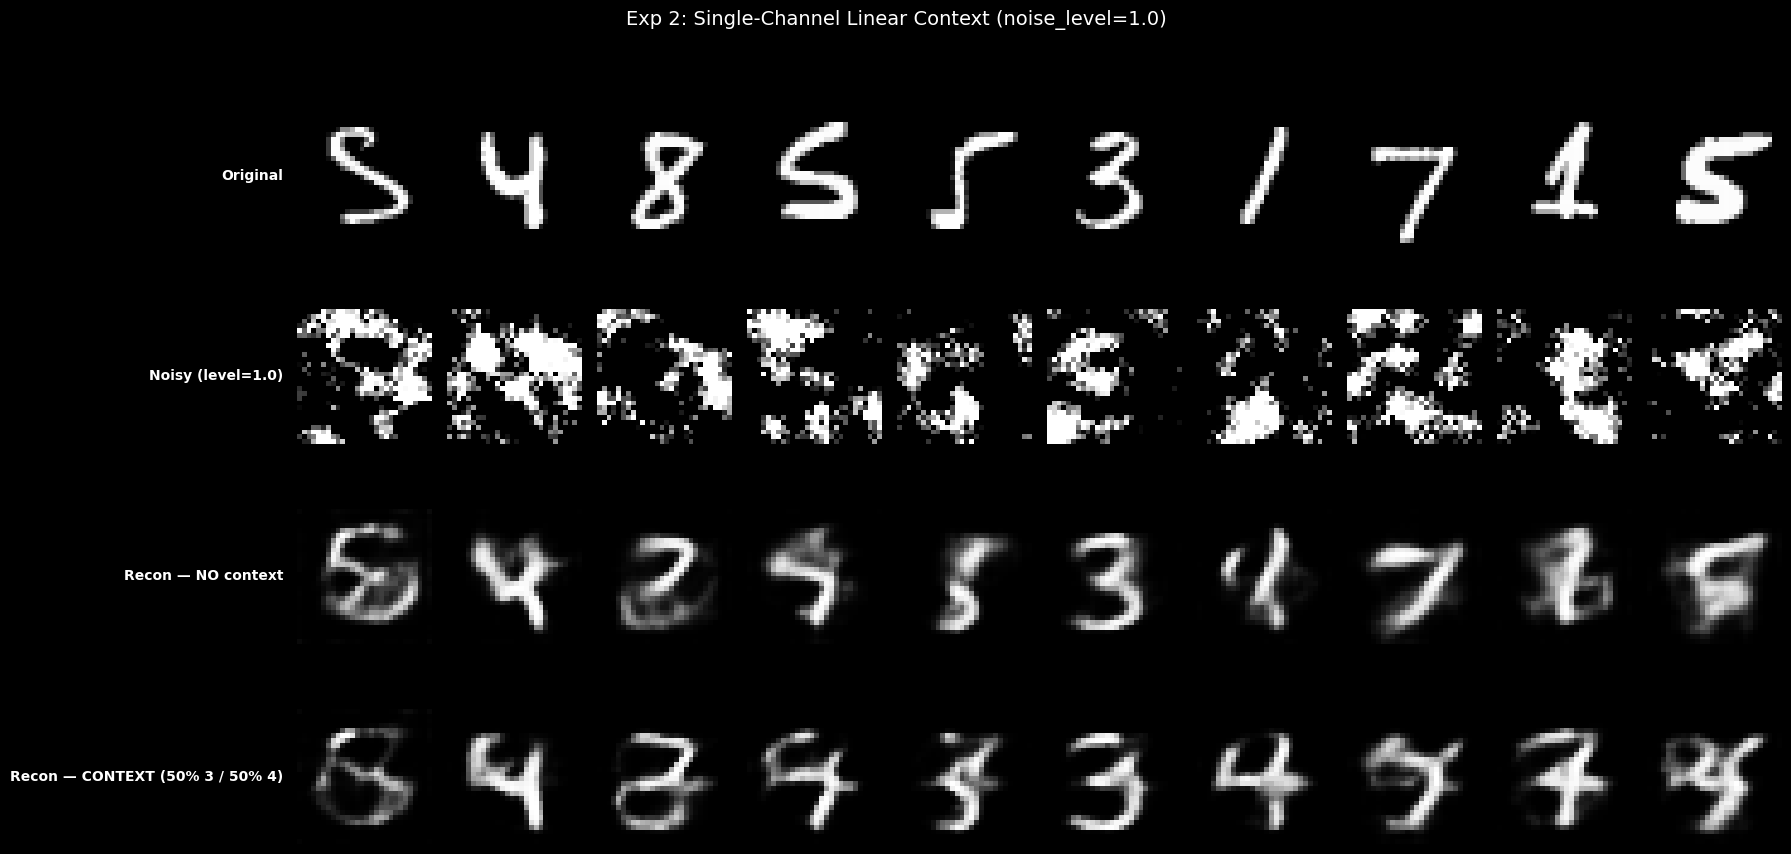

Saved: ./output\03_exp2_histogram.png


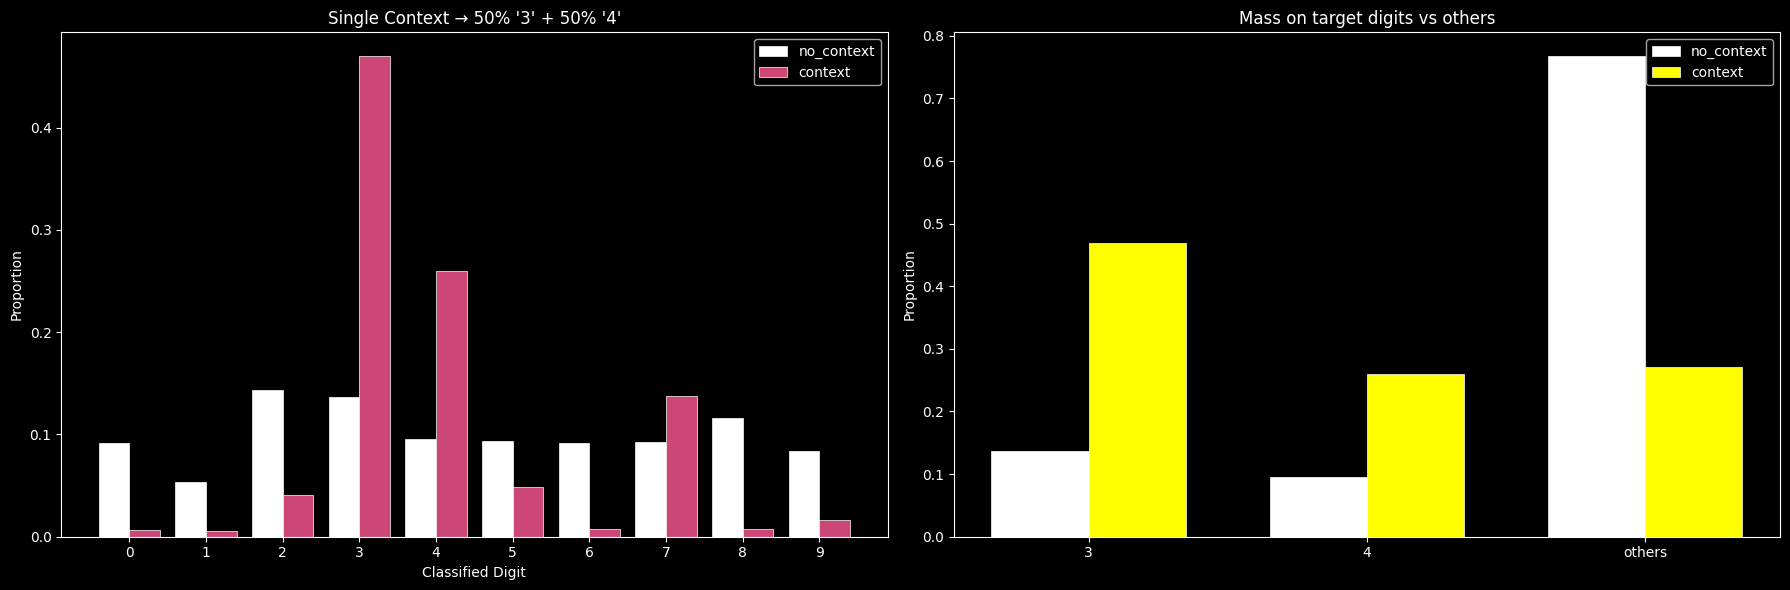


Digit 3: 0.470, Digit 4: 0.260
Combined target mass: 0.729, Balance ratio: 0.553
→ BIMODAL


In [9]:
# Sample images
fig = plot_sample_images(
    row_labels=[
        'Original', f'Noisy (level={EXTREME_NOISE})',
        'Recon — NO context', f'Recon — CONTEXT (50% {bc.digit_a} / 50% {bc.digit_b})',
    ],
    row_data=[exp2['samples']['original'], exp2['samples']['noisy'],
              exp2['samples']['recon_no_ctx'], exp2['samples']['recon_ctx']],
    title=f"Exp 2: Single-Channel Linear Context (noise_level={EXTREME_NOISE})"
)
save_figure(fig, "03_exp2_samples")
plt.show()

# Category histogram + target zoom
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_category_histogram({'no_context': exp2['hist_no_ctx'], 'context': exp2['hist_ctx']}, ax=axes[0])
axes[0].set_title(f"Single Context → 50% '{bc.digit_a}' + 50% '{bc.digit_b}'")

target_labels = [str(bc.digit_a), str(bc.digit_b), 'others']
no_ctx_vals = [exp2['hist_no_ctx'][bc.digit_a], exp2['hist_no_ctx'][bc.digit_b],
               1 - exp2['hist_no_ctx'][bc.digit_a] - exp2['hist_no_ctx'][bc.digit_b]]
ctx_vals = [exp2['hist_ctx'][bc.digit_a], exp2['hist_ctx'][bc.digit_b],
            1 - exp2['hist_ctx'][bc.digit_a] - exp2['hist_ctx'][bc.digit_b]]

x = np.arange(3)
w = 0.35
axes[1].bar(x - w/2, no_ctx_vals, w, label='no_context', color='white', edgecolor='white', linewidth=0.5)
axes[1].bar(x + w/2, ctx_vals, w, label='context', color='#FFFF00', edgecolor='white', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(target_labels)
axes[1].set_ylabel('Proportion')
axes[1].set_title('Mass on target digits vs others')
axes[1].legend()

plt.tight_layout()
save_figure(fig, "03_exp2_histogram")
plt.show()

# Bimodality metrics
mass_a = exp2['hist_ctx'][bc.digit_a]
mass_b = exp2['hist_ctx'][bc.digit_b]
mass_total = mass_a + mass_b
ratio = min(mass_a, mass_b) / max(mass_a, mass_b) if max(mass_a, mass_b) > 0 else 0

print(f"\nDigit {bc.digit_a}: {mass_a:.3f}, Digit {bc.digit_b}: {mass_b:.3f}")
print(f"Combined target mass: {mass_total:.3f}, Balance ratio: {ratio:.3f}")
if ratio > 0.5 and mass_total > 0.3:
    print("→ BIMODAL")
elif mass_total > 0.3:
    print("→ SKEWED")
else:
    print("→ BLURRED AVERAGE")

## Exp 2: Per-Digit Breakdown — Basin of Attraction Analysis
For each original digit class, what proportion gets classified as digit 3 vs 4 (vs other) after context?
If the linear context creates a true bimodal prior, then:
- Original 3s → reconstruct as 3 (already in that basin)
- Original 4s → reconstruct as 4 (already in that basin)
- Other digits → split between 3 and 4 depending on their latent proximity

Digit order (most 4-like → most 3-like): [4, 9, 7, 6, 1, 2, 0, 8, 5, 3]
Saved: ./output\03_exp2_basin_analysis.png


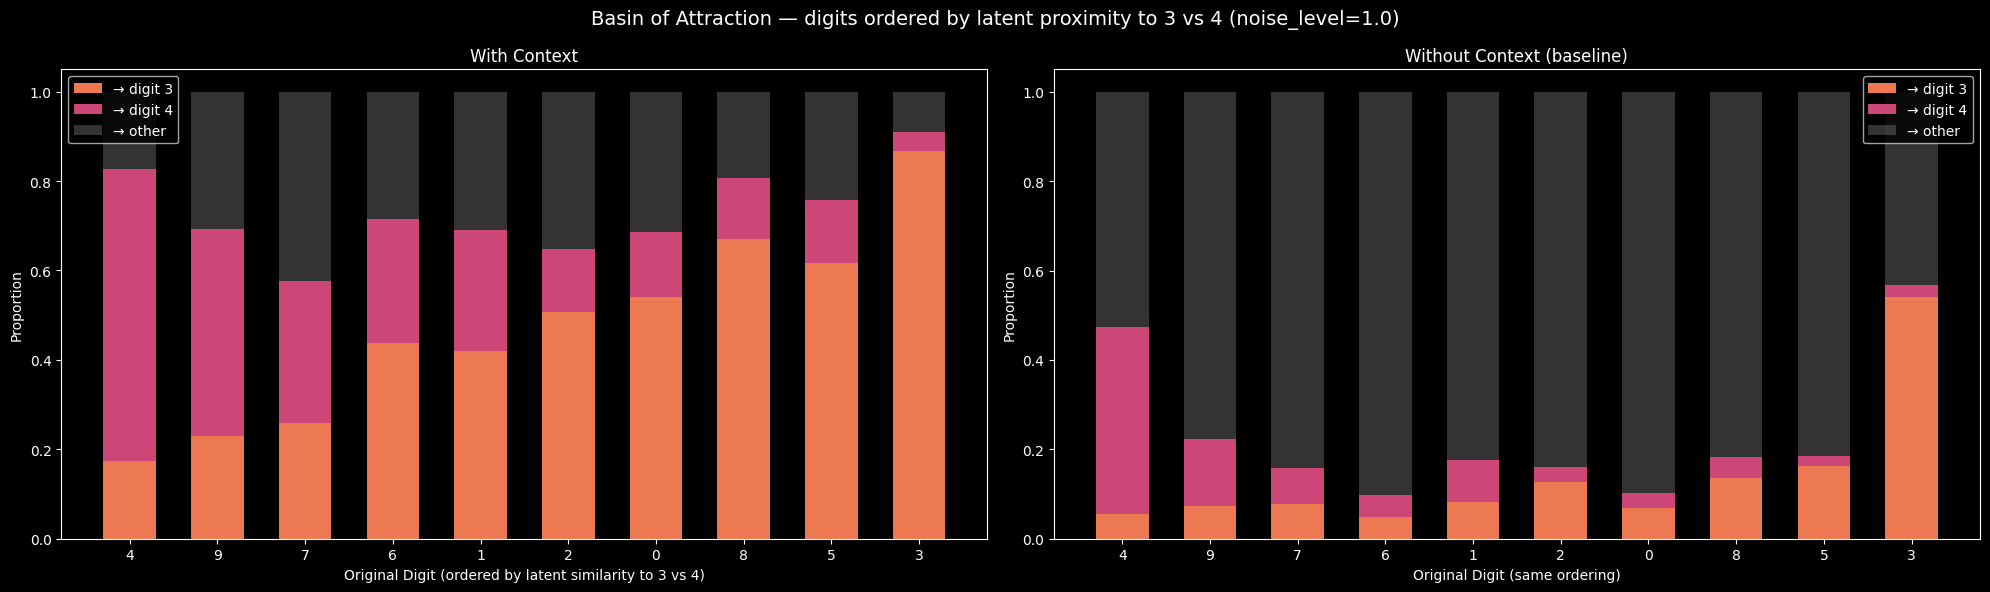

  Original 4 (score -11.15): → 3: 0.174  → 4: 0.653  → other: 0.173
  Original 9 (score -4.94): → 3: 0.230  → 4: 0.463  → other: 0.307
  Original 7 (score -2.45): → 3: 0.258  → 4: 0.319  → other: 0.423
  Original 6 (score -1.11): → 3: 0.437  → 4: 0.278  → other: 0.285
  Original 1 (score -0.78): → 3: 0.419  → 4: 0.270  → other: 0.310
  Original 2 (score +1.52): → 3: 0.507  → 4: 0.141  → other: 0.352
  Original 0 (score +1.67): → 3: 0.542  → 4: 0.145  → other: 0.313
  Original 8 (score +2.26): → 3: 0.671  → 4: 0.136  → other: 0.193
  Original 5 (score +3.96): → 3: 0.618  → 4: 0.139  → other: 0.243
  Original 3 (score +11.15): → 3: 0.867  → 4: 0.043  → other: 0.090


In [10]:
# Compute centroids and similarity ordering
centroids = compute_digit_centroids(prob_ae.encoder, test_dl, config, device)
digit_order, scores = compute_similarity_order(centroids, bc.digit_a, bc.digit_b)
print("Digit order (most 4-like → most 3-like):", digit_order)

# Per-digit breakdown with and without context
prop_a_ctx, prop_b_ctx, prop_other_ctx = compute_basin_proportions(
    exp2['orig_labels'], exp2['preds_ctx'], bc.digit_a, bc.digit_b)
prop_a_nc, prop_b_nc, prop_other_nc = compute_basin_proportions(
    exp2['orig_labels'], exp2['preds_no_ctx'], bc.digit_a, bc.digit_b)

# Plot
fig = plot_basin_analysis(
    prop_a_ctx, prop_b_ctx, prop_other_ctx,
    prop_a_nc, prop_b_nc, prop_other_nc,
    digit_order, bc.digit_a, bc.digit_b, noise_level=EXTREME_NOISE
)
save_figure(fig, "03_exp2_basin_analysis")
plt.show()

# Summary
for d in digit_order:
    print(f"  Original {d} (score {scores[d]:+.2f}): "
          f"→ {bc.digit_a}: {prop_a_ctx[d]:.3f}  → {bc.digit_b}: {prop_b_ctx[d]:.3f}  "
          f"→ other: {prop_other_ctx[d]:.3f}")

## Latent Centroid Similarity Structure
Pairwise distances between the 10 digit centroids in latent space, reordered by
hierarchical clustering. This reveals the continuous similarity landscape that
underlies the binary basin analysis above.

Saved: ./output\03_centroid_rdm.png


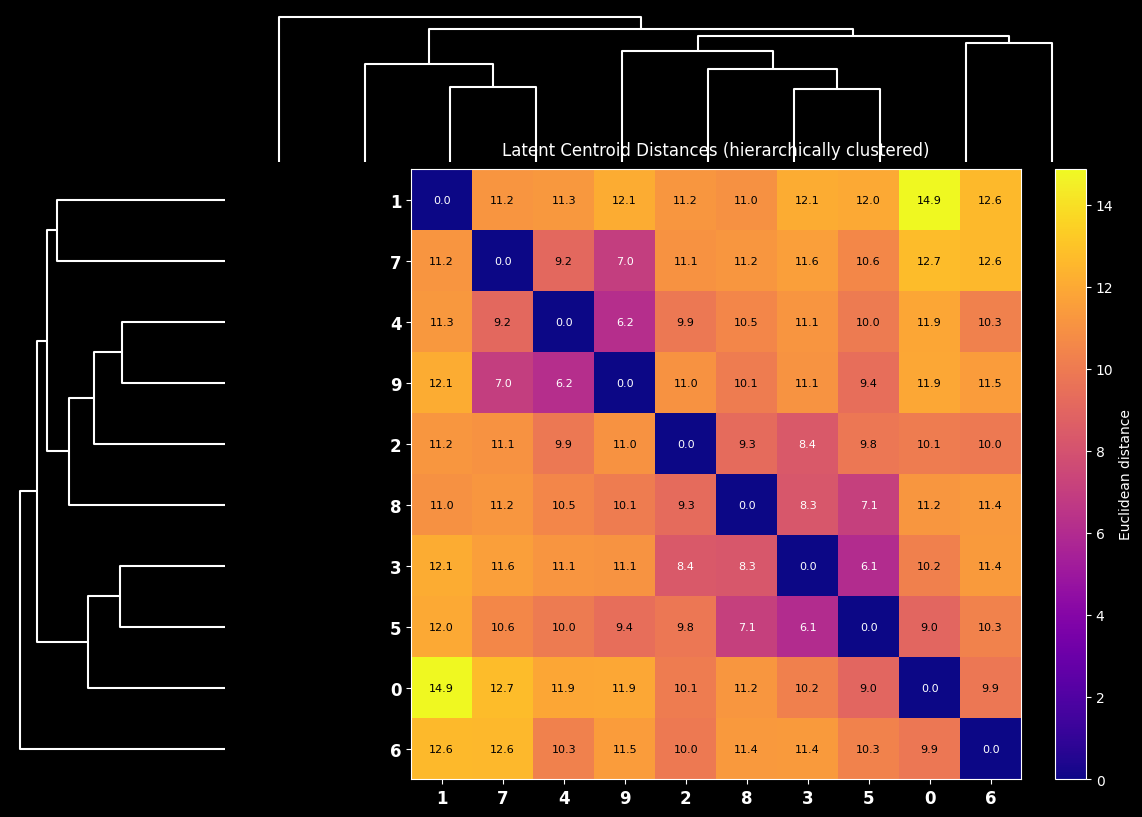

Saved: ./output\03_centroid_rdm_cosine.png


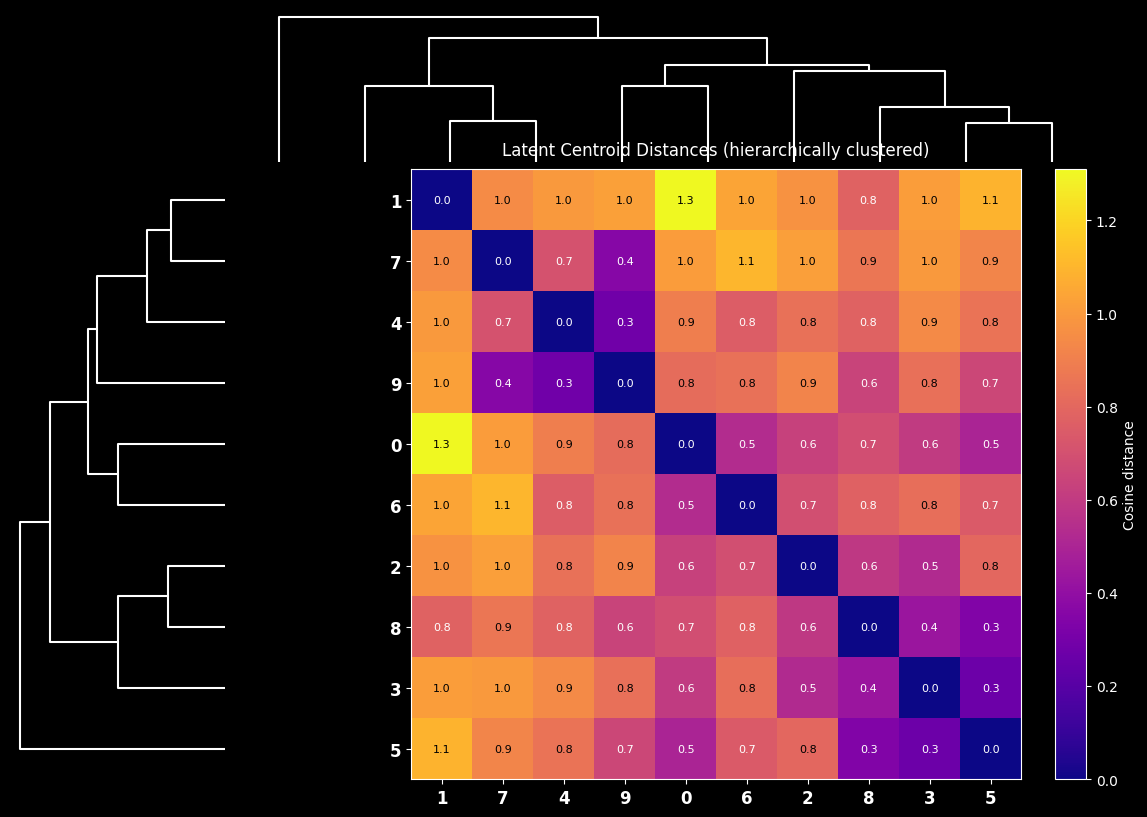

Euclidean cluster order: [1, 7, 4, 9, 2, 8, 3, 5, 0, 6]
Cosine cluster order:    [1, 7, 4, 9, 0, 6, 2, 8, 3, 5]

Digits 3 and 4 Euclidean distance: 11.15
Nearest neighbor of 3: digit 5
Nearest neighbor of 4: digit 9


In [11]:
# Compute and plot centroid RDM with hierarchical clustering
rdm, linkage_mat = compute_centroid_rdm(centroids, metric='euclidean')

fig, cluster_order = plot_centroid_rdm(rdm, linkage_mat, metric='euclidean')
save_figure(fig, "03_centroid_rdm")
plt.show()

# Also compute cosine for comparison
rdm_cos, linkage_cos = compute_centroid_rdm(centroids, metric='cosine')
fig_cos, order_cos = plot_centroid_rdm(rdm_cos, linkage_cos, metric='cosine')
save_figure(fig_cos, "03_centroid_rdm_cosine")
plt.show()

print(f"Euclidean cluster order: {cluster_order}")
print(f"Cosine cluster order:    {list(order_cos)}")
print(f"\nDigits {bc.digit_a} and {bc.digit_b} Euclidean distance: {rdm[bc.digit_a, bc.digit_b]:.2f}")
print(f"Nearest neighbor of {bc.digit_a}: digit {[d for d in np.argsort(rdm[bc.digit_a]) if d != bc.digit_a][0]}")
print(f"Nearest neighbor of {bc.digit_b}: digit {[d for d in np.argsort(rdm[bc.digit_b]) if d != bc.digit_b][0]}")

## Bayesian Optimality Analysis
Project each noisy image's latent code onto the axis connecting the digit 3 and digit 4 centroids.
Bin by projection value and compute P(→3 | classified as 3 or 4).
Fit a sigmoid to the network's behaviour and compare to the **non-parametric Bayesian optimal**
prediction derived from KDE-estimated class-conditional latent distributions and the training prior.

In [ ]:
# Per-image sigmoid data
bin_centers, p_a, bin_counts, projections = compute_sigmoid_data(
    exp2['noisy_latents'], exp2['preds_ctx'], centroids, bc.digit_a, bc.digit_b, n_bins=25
)

# Fit sigmoid to observed data
fitted_params, fitted_curve = fit_sigmoid(bin_centers, p_a, bin_counts)

# Non-parametric Bayesian optimal prediction
np_bayes = compute_nonparametric_bayesian(
    exp2['noisy_latents'], exp2['orig_labels'], centroids,
    bc.digit_a, bc.digit_b, prior_a=0.5
)

# Plot
fig = plot_bayesian_sigmoid(
    bin_centers, p_a, bin_counts, fitted_curve, fitted_params,
    np_bayes['x_range'], np_bayes['bayesian_p_a'], bc.digit_a, bc.digit_b,
    noise_std=np_bayes['sigma_a']
)
save_figure(fig, "03_bayesian_sigmoid")
plt.show()

print(f"\nLatent geometry:")
print(f"  Centroid separation (Δμ): {np_bayes['delta_mu']:.2f}")
print(f"  Within-class noise σ_a: {np_bayes['sigma_a']:.2f}")
print(f"  Within-class noise σ_b: {np_bayes['sigma_b']:.2f}")
print(f"  NP Bayesian midpoint: {np_bayes['bayesian_midpoint']:.2f}")
print(f"  NP Bayesian slope at midpoint: {np_bayes['bayesian_slope_at_midpoint']:.2f}")
if fitted_params is not None:
    alpha, beta, gamma, delta = fitted_params
    print(f"\nFitted sigmoid:")
    print(f"  Midpoint: {alpha:.2f}, Slope: {beta:.2f}")
    print(f"  Asymptotes: [{gamma:.2f}, {delta:.2f}]")
    np_slope_ratio = beta / np_bayes['bayesian_slope_at_midpoint'] if np_bayes['bayesian_slope_at_midpoint'] != 0 else float('nan')
    print(f"\n  Slope ratio (fitted/NP optimal): {np_slope_ratio:.2f}")
    if np_slope_ratio > 0.8:
        print("  → Near-optimal: autoencoder approximates Bayesian inference")
    elif np_slope_ratio > 0.5:
        print("  → Sub-optimal but structured: sigmoidal basin transition")
    else:
        print("  → Under-confident relative to Bayesian optimal")

## Control Analysis 1: Classifier Bias Check
Before attributing the 3-bias to the autoencoder, verify that the CNN classifier itself
doesn't have asymmetric accuracy or confusion between digits 3 and 4.

In [ ]:
# Full confusion matrix on clean test digits
from sklearn.metrics import confusion_matrix

classifier.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_dl:
        images = images.to(device)
        preds = classifier.predict(images).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)

# Plot full confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='plasma')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Classifier Confusion Matrix (clean test set)')
for i in range(10):
    for j in range(10):
        color = 'black' if cm[i, j] > cm.max() / 2 else 'white'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=7, color=color)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
save_figure(fig, "03_classifier_confusion")
plt.show()

# Per-class accuracy for target digits
da, db = bc.digit_a, bc.digit_b
n_true_a = (all_labels == da).sum()
n_true_b = (all_labels == db).sum()
acc_a = cm[da, da] / n_true_a
acc_b = cm[db, db] / n_true_b
confuse_a_as_b = cm[da, db] / n_true_a
confuse_b_as_a = cm[db, da] / n_true_b

print(f"\nClassifier accuracy on clean digits:")
print(f"  Digit {da}: {acc_a:.4f} ({cm[da, da]}/{n_true_a})")
print(f"  Digit {db}: {acc_b:.4f} ({cm[db, db]}/{n_true_b})")
print(f"  {da}→{db} confusion: {confuse_a_as_b:.4f} ({cm[da, db]}/{n_true_a})")
print(f"  {db}→{da} confusion: {confuse_b_as_a:.4f} ({cm[db, da]}/{n_true_b})")
print(f"\n  Classifier bias toward {da}: {confuse_b_as_a - confuse_a_as_b:+.4f}")
if abs(confuse_b_as_a - confuse_a_as_b) < 0.01:
    print("  → Negligible classifier bias between these digits")
else:
    print(f"  → Classifier is more likely to confuse {db}→{da}" if confuse_b_as_a > confuse_a_as_b
          else f"  → Classifier is more likely to confuse {da}→{db}")

## Control Analysis 2: Swap Digits (1 vs 7)
Repeat the full probabilistic bimodal experiment with a different digit pair.
If the 3-bias in Exp 2 is an artifact of the method, it should appear here too (as a bias toward one digit).
If it's specific to the 3/4 asymmetry, the new pair may show a different or no bias.

In [14]:
CTRL_DIGIT_A = 1
CTRL_DIGIT_B = 7
CTRL_CONTEXT_ID = 4  # use a different channel to avoid any residual from Exp 2

ctrl_path = os.path.join(config.pretrained_dir, f'prob_bimodal_{CTRL_DIGIT_A}v{CTRL_DIGIT_B}_deep_autoencoder.pth')

# Start from the SAME clean baseline
ctrl_ae = Autoencoder(mc.capacity, mc.latent_dims, mc.context_dim).to(device)
ctrl_ae.load_state_dict(torch.load(baseline_path, map_location=device, weights_only=True))

if os.path.isfile(ctrl_path):
    ctrl_ae.load_state_dict(torch.load(ctrl_path, map_location=device, weights_only=True))
    print(f"Loaded pretrained control model ({CTRL_DIGIT_A} vs {CTRL_DIGIT_B}).")
else:
    freeze_except_context(ctrl_ae)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, ctrl_ae.parameters()), lr=config.training.lr)

    print(f"Control training: context[{CTRL_CONTEXT_ID}] -> 50% digit {CTRL_DIGIT_A}, 50% digit {CTRL_DIGIT_B}")
    for epoch in range(bc.epochs_association):
        total_loss = 0
        for image_batch, label_batch in train_dl:
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)

            context_batch = generate_context(
                image_batch.size(0), signal_level=None,
                noise_level=bc.noise_level, category_id=0,
                context_dim=mc.context_dim, device=device
            )

            for target in [CTRL_DIGIT_A, CTRL_DIGIT_B]:
                idx = (label_batch == target).nonzero(as_tuple=True)[0]
                if len(idx) > 0:
                    context_batch[idx] = generate_context(
                        len(idx), signal_level=bc.signal_level,
                        noise_level=bc.noise_level, category_id=CTRL_CONTEXT_ID,
                        context_dim=mc.context_dim, device=device
                    )

            noisy_batch = add_noise(
                image_batch, noise_level=nc.training_noise_level,
                correlated=nc.correlated, uncorrelated=nc.uncorrelated,
                kernel_size=nc.kernel_size, sigma=nc.sigma
            )
            reconstructed = ctrl_ae(noisy_batch, context_batch)
            loss = F.mse_loss(reconstructed, image_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_dl)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{bc.epochs_association}, Loss: {avg_loss:.6f}")

    torch.save(ctrl_ae.state_dict(), ctrl_path)
    print(f"Control model saved to {ctrl_path}")

ctrl_ae.eval()
print(f"Control model ({CTRL_DIGIT_A} vs {CTRL_DIGIT_B}) ready.")

Loaded pretrained control model (1 vs 7).
Control model (1 vs 7) ready.


In [15]:
# Noise corruption test for control pair
ctrl_exp = run_corruption_test(
    ctrl_ae, classifier, test_dl, noise_level=EXTREME_NOISE,
    context_signal_level=config.context.eval_signal_level,
    context_id=CTRL_CONTEXT_ID, config=config, device=device
)

print(f"Control ({CTRL_DIGIT_A} vs {CTRL_DIGIT_B}):")
print("No context:   ", np.round(ctrl_exp['hist_no_ctx'], 3))
print("With context: ", np.round(ctrl_exp['hist_ctx'], 3))

# Bimodality metrics
ctrl_mass_a = ctrl_exp['hist_ctx'][CTRL_DIGIT_A]
ctrl_mass_b = ctrl_exp['hist_ctx'][CTRL_DIGIT_B]
ctrl_mass_total = ctrl_mass_a + ctrl_mass_b
ctrl_ratio = min(ctrl_mass_a, ctrl_mass_b) / max(ctrl_mass_a, ctrl_mass_b) if max(ctrl_mass_a, ctrl_mass_b) > 0 else 0

print(f"\nDigit {CTRL_DIGIT_A}: {ctrl_mass_a:.3f}, Digit {CTRL_DIGIT_B}: {ctrl_mass_b:.3f}")
print(f"Combined target mass: {ctrl_mass_total:.3f}, Balance ratio: {ctrl_ratio:.3f}")

Control (1 vs 7):
No context:    [0.088 0.05  0.14  0.144 0.098 0.093 0.092 0.093 0.126 0.075]
With context:  [0.014 0.142 0.056 0.144 0.004 0.081 0.004 0.521 0.021 0.014]

Digit 1: 0.142, Digit 7: 0.521
Combined target mass: 0.663, Balance ratio: 0.272


Saved: ./output\03_ctrl_1v7_samples.png


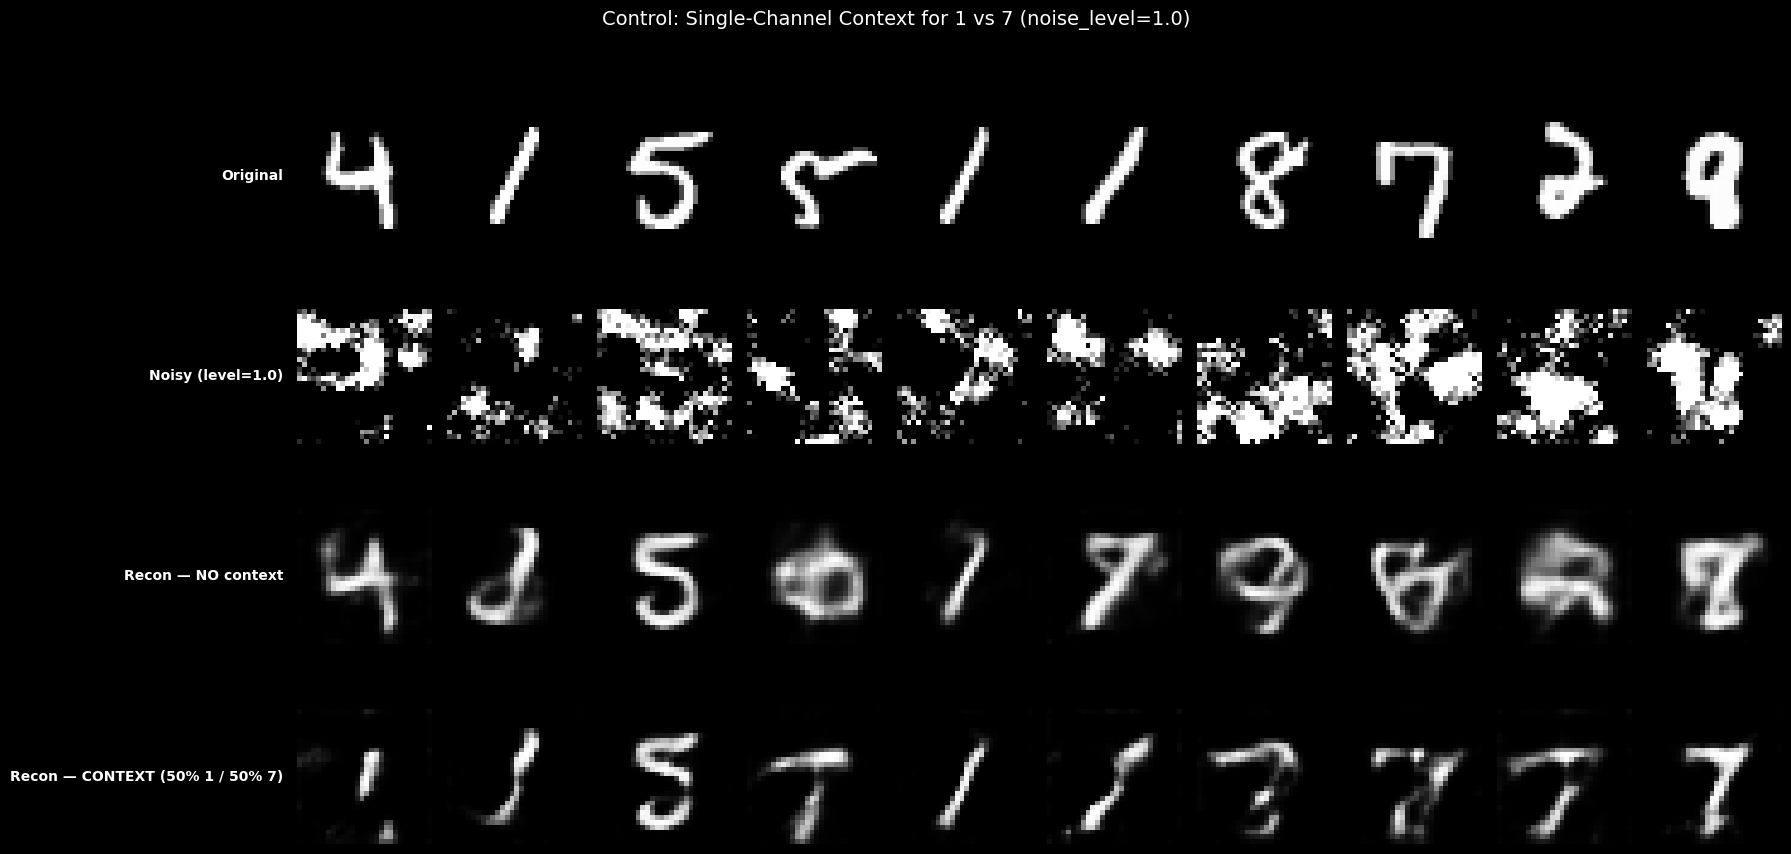

Saved: ./output\03_ctrl_1v7_histogram.png


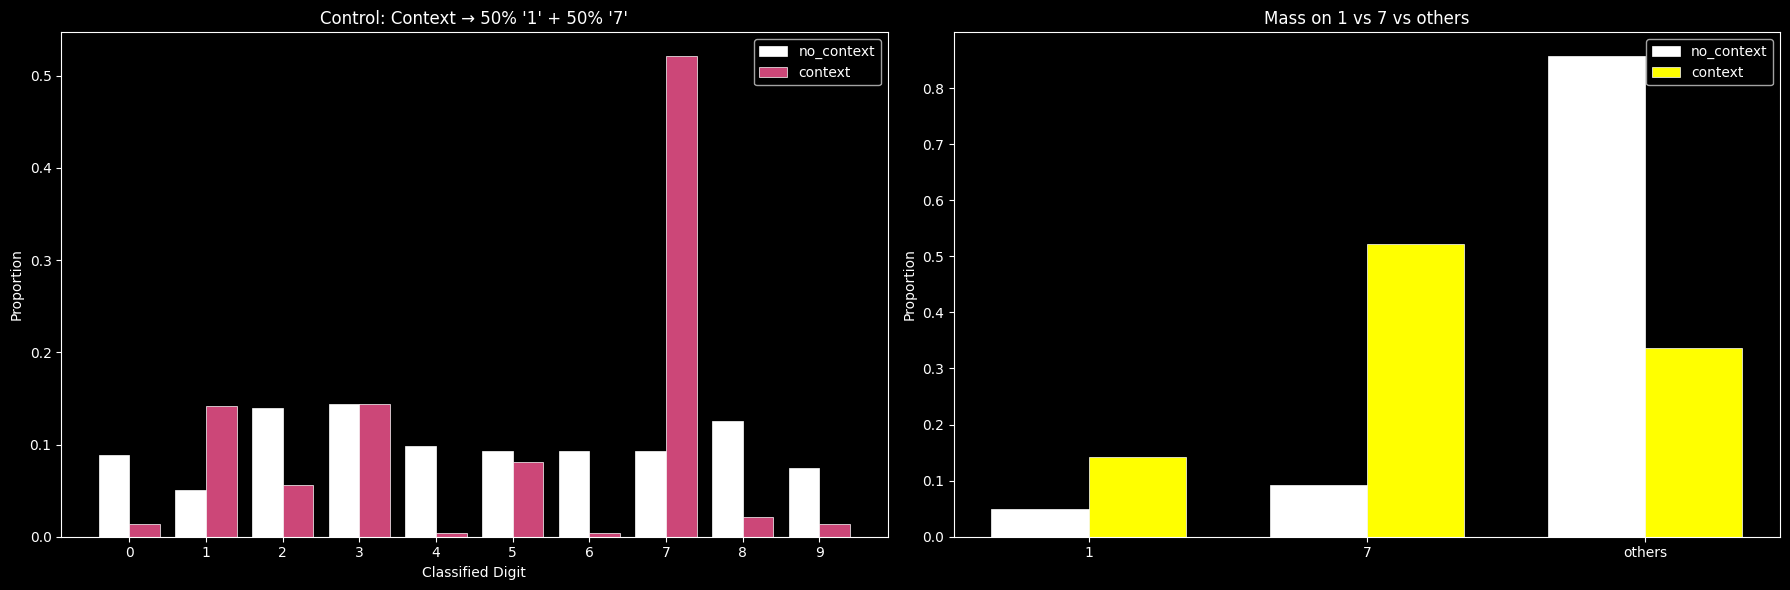

In [16]:
# Sample images + histogram for control pair
fig = plot_sample_images(
    row_labels=[
        'Original', f'Noisy (level={EXTREME_NOISE})',
        'Recon — NO context', f'Recon — CONTEXT (50% {CTRL_DIGIT_A} / 50% {CTRL_DIGIT_B})',
    ],
    row_data=[ctrl_exp['samples']['original'], ctrl_exp['samples']['noisy'],
              ctrl_exp['samples']['recon_no_ctx'], ctrl_exp['samples']['recon_ctx']],
    title=f"Control: Single-Channel Context for {CTRL_DIGIT_A} vs {CTRL_DIGIT_B} (noise_level={EXTREME_NOISE})"
)
save_figure(fig, f"03_ctrl_{CTRL_DIGIT_A}v{CTRL_DIGIT_B}_samples")
plt.show()

# Histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plot_category_histogram({'no_context': ctrl_exp['hist_no_ctx'], 'context': ctrl_exp['hist_ctx']}, ax=axes[0])
axes[0].set_title(f"Control: Context → 50% '{CTRL_DIGIT_A}' + 50% '{CTRL_DIGIT_B}'")

target_labels = [str(CTRL_DIGIT_A), str(CTRL_DIGIT_B), 'others']
no_ctx_vals = [ctrl_exp['hist_no_ctx'][CTRL_DIGIT_A], ctrl_exp['hist_no_ctx'][CTRL_DIGIT_B],
               1 - ctrl_exp['hist_no_ctx'][CTRL_DIGIT_A] - ctrl_exp['hist_no_ctx'][CTRL_DIGIT_B]]
ctx_vals = [ctrl_exp['hist_ctx'][CTRL_DIGIT_A], ctrl_exp['hist_ctx'][CTRL_DIGIT_B],
            1 - ctrl_exp['hist_ctx'][CTRL_DIGIT_A] - ctrl_exp['hist_ctx'][CTRL_DIGIT_B]]
x = np.arange(3)
w = 0.35
axes[1].bar(x - w/2, no_ctx_vals, w, label='no_context', color='white', edgecolor='white', linewidth=0.5)
axes[1].bar(x + w/2, ctx_vals, w, label='context', color='#FFFF00', edgecolor='white', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(target_labels)
axes[1].set_ylabel('Proportion')
axes[1].set_title(f'Mass on {CTRL_DIGIT_A} vs {CTRL_DIGIT_B} vs others')
axes[1].legend()
plt.tight_layout()
save_figure(fig, f"03_ctrl_{CTRL_DIGIT_A}v{CTRL_DIGIT_B}_histogram")
plt.show()

Digit order (most 7-like → most 1-like): [7, 9, 4, 0, 5, 3, 2, 6, 8, 1]
Saved: ./output\03_ctrl_1v7_basin.png


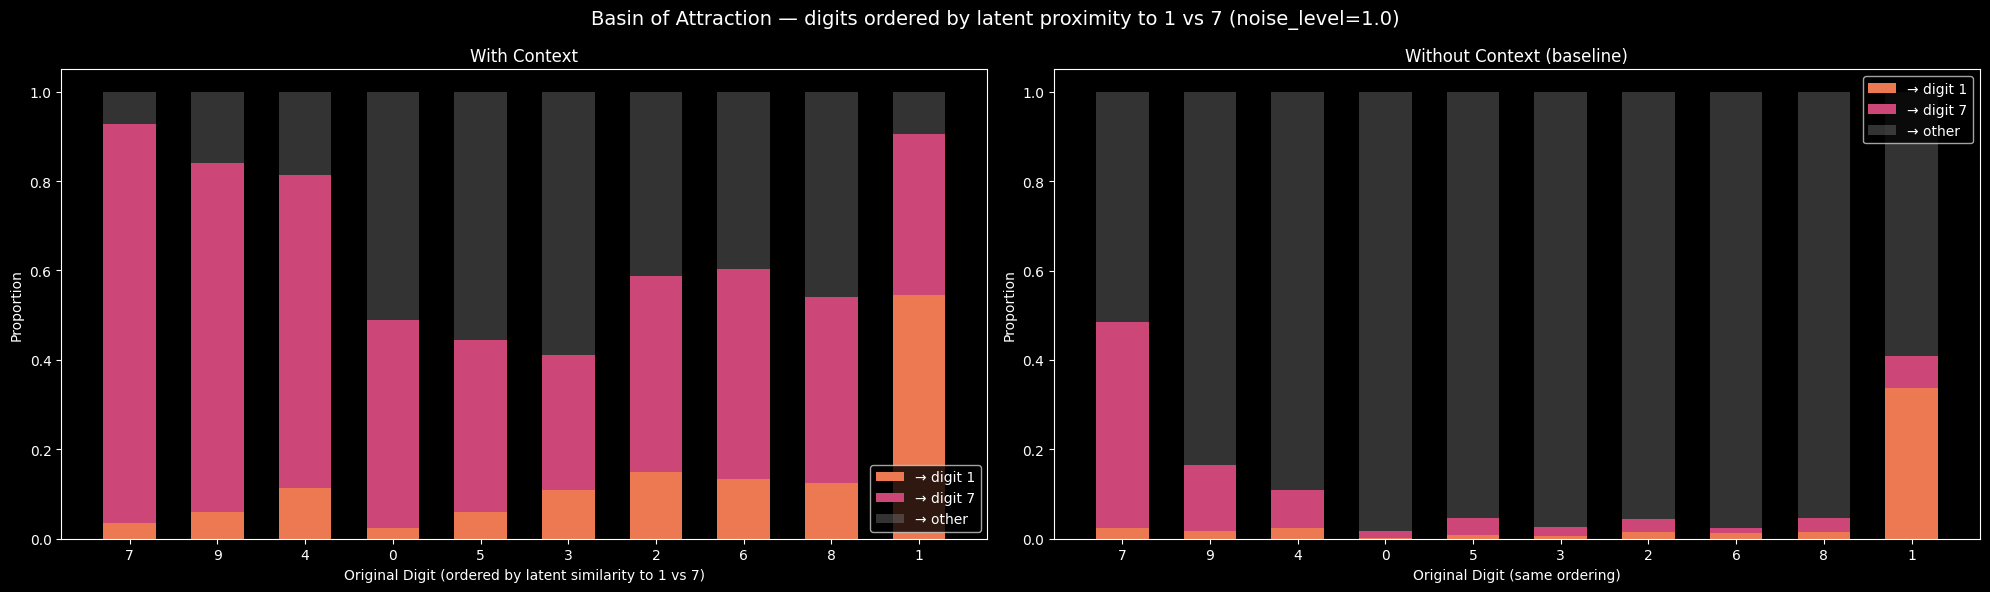

In [17]:
# Basin of attraction for control pair
ctrl_centroids = compute_digit_centroids(ctrl_ae.encoder, test_dl, config, device)
ctrl_digit_order, ctrl_scores = compute_similarity_order(ctrl_centroids, CTRL_DIGIT_A, CTRL_DIGIT_B)
print(f"Digit order (most {CTRL_DIGIT_B}-like → most {CTRL_DIGIT_A}-like):", ctrl_digit_order)

ctrl_prop_a_ctx, ctrl_prop_b_ctx, ctrl_prop_other_ctx = compute_basin_proportions(
    ctrl_exp['orig_labels'], ctrl_exp['preds_ctx'], CTRL_DIGIT_A, CTRL_DIGIT_B)
ctrl_prop_a_nc, ctrl_prop_b_nc, ctrl_prop_other_nc = compute_basin_proportions(
    ctrl_exp['orig_labels'], ctrl_exp['preds_no_ctx'], CTRL_DIGIT_A, CTRL_DIGIT_B)

fig = plot_basin_analysis(
    ctrl_prop_a_ctx, ctrl_prop_b_ctx, ctrl_prop_other_ctx,
    ctrl_prop_a_nc, ctrl_prop_b_nc, ctrl_prop_other_nc,
    ctrl_digit_order, CTRL_DIGIT_A, CTRL_DIGIT_B, noise_level=EXTREME_NOISE
)
save_figure(fig, f"03_ctrl_{CTRL_DIGIT_A}v{CTRL_DIGIT_B}_basin")
plt.show()

In [ ]:
# Bayesian sigmoid for control pair
ctrl_bin_centers, ctrl_p_a, ctrl_bin_counts, ctrl_projections = compute_sigmoid_data(
    ctrl_exp['noisy_latents'], ctrl_exp['preds_ctx'], ctrl_centroids,
    CTRL_DIGIT_A, CTRL_DIGIT_B, n_bins=25
)

ctrl_fitted_params, ctrl_fitted_curve = fit_sigmoid(ctrl_bin_centers, ctrl_p_a, ctrl_bin_counts)

# Non-parametric Bayesian optimal prediction for control pair
ctrl_np_bayes = compute_nonparametric_bayesian(
    ctrl_exp['noisy_latents'], ctrl_exp['orig_labels'], ctrl_centroids,
    CTRL_DIGIT_A, CTRL_DIGIT_B, prior_a=0.5
)

fig = plot_bayesian_sigmoid(
    ctrl_bin_centers, ctrl_p_a, ctrl_bin_counts, ctrl_fitted_curve, ctrl_fitted_params,
    ctrl_np_bayes['x_range'], ctrl_np_bayes['bayesian_p_a'], CTRL_DIGIT_A, CTRL_DIGIT_B,
    noise_std=ctrl_np_bayes['sigma_a']
)
save_figure(fig, f"03_ctrl_{CTRL_DIGIT_A}v{CTRL_DIGIT_B}_bayesian_sigmoid")
plt.show()

print(f"\nControl ({CTRL_DIGIT_A} vs {CTRL_DIGIT_B}) — Latent geometry:")
print(f"  Centroid separation (Δμ): {ctrl_np_bayes['delta_mu']:.2f}")
print(f"  Within-class noise σ_a: {ctrl_np_bayes['sigma_a']:.2f}")
print(f"  Within-class noise σ_b: {ctrl_np_bayes['sigma_b']:.2f}")
print(f"  NP Bayesian midpoint: {ctrl_np_bayes['bayesian_midpoint']:.2f}")
print(f"  NP Bayesian slope at midpoint: {ctrl_np_bayes['bayesian_slope_at_midpoint']:.2f}")
if ctrl_fitted_params is not None:
    alpha, beta, gamma, delta = ctrl_fitted_params
    print(f"\nFitted sigmoid:")
    print(f"  Midpoint: {alpha:.2f}, Slope: {beta:.2f}")
    print(f"  Asymptotes: [{gamma:.2f}, {delta:.2f}]")
    ctrl_np_slope_ratio = beta / ctrl_np_bayes['bayesian_slope_at_midpoint'] if ctrl_np_bayes['bayesian_slope_at_midpoint'] != 0 else float('nan')
    print(f"  Slope ratio (fitted/NP optimal): {ctrl_np_slope_ratio:.2f}")

In [ ]:
# Side-by-side comparison: 3v4 vs 1v7
print("=" * 70)
print("COMPARISON: Exp 2 (3 vs 4) vs Control (1 vs 7)")
print("=" * 70)

print(f"\n{'Metric':<35} {'3 vs 4':>12} {'1 vs 7':>12}")
print("-" * 60)

# Bimodality
print(f"{'Target mass (digit_a)':<35} {exp2['hist_ctx'][bc.digit_a]:>12.3f} {ctrl_exp['hist_ctx'][CTRL_DIGIT_A]:>12.3f}")
print(f"{'Target mass (digit_b)':<35} {exp2['hist_ctx'][bc.digit_b]:>12.3f} {ctrl_exp['hist_ctx'][CTRL_DIGIT_B]:>12.3f}")
r34 = min(exp2['hist_ctx'][bc.digit_a], exp2['hist_ctx'][bc.digit_b]) / max(exp2['hist_ctx'][bc.digit_a], exp2['hist_ctx'][bc.digit_b]) if max(exp2['hist_ctx'][bc.digit_a], exp2['hist_ctx'][bc.digit_b]) > 0 else 0
r17 = min(ctrl_exp['hist_ctx'][CTRL_DIGIT_A], ctrl_exp['hist_ctx'][CTRL_DIGIT_B]) / max(ctrl_exp['hist_ctx'][CTRL_DIGIT_A], ctrl_exp['hist_ctx'][CTRL_DIGIT_B]) if max(ctrl_exp['hist_ctx'][CTRL_DIGIT_A], ctrl_exp['hist_ctx'][CTRL_DIGIT_B]) > 0 else 0
print(f"{'Balance ratio (min/max)':<35} {r34:>12.3f} {r17:>12.3f}")

# Latent geometry
print(f"\n{'Centroid separation (Δμ)':<35} {np_bayes['delta_mu']:>12.2f} {ctrl_np_bayes['delta_mu']:>12.2f}")
print(f"{'Within-class noise σ_a':<35} {np_bayes['sigma_a']:>12.2f} {ctrl_np_bayes['sigma_a']:>12.2f}")
print(f"{'Within-class noise σ_b':<35} {np_bayes['sigma_b']:>12.2f} {ctrl_np_bayes['sigma_b']:>12.2f}")

# Bayesian comparison (non-parametric)
print(f"\n{'NP Bayesian slope at midpoint':<35} {np_bayes['bayesian_slope_at_midpoint']:>12.2f} {ctrl_np_bayes['bayesian_slope_at_midpoint']:>12.2f}")
print(f"{'NP Bayesian midpoint':<35} {np_bayes['bayesian_midpoint']:>12.2f} {ctrl_np_bayes['bayesian_midpoint']:>12.2f}")
if fitted_params is not None:
    print(f"{'Fitted slope':<35} {fitted_params[1]:>12.2f}", end="")
else:
    print(f"{'Fitted slope':<35} {'N/A':>12}", end="")
if ctrl_fitted_params is not None:
    print(f" {ctrl_fitted_params[1]:>12.2f}")
else:
    print(f" {'N/A':>12}")

if fitted_params is not None:
    print(f"{'Fitted midpoint':<35} {fitted_params[0]:>12.2f}", end="")
else:
    print(f"{'Fitted midpoint':<35} {'N/A':>12}", end="")
if ctrl_fitted_params is not None:
    print(f" {ctrl_fitted_params[0]:>12.2f}")
else:
    print(f" {'N/A':>12}")

if fitted_params is not None and ctrl_fitted_params is not None:
    sr_34 = fitted_params[1] / np_bayes['bayesian_slope_at_midpoint'] if np_bayes['bayesian_slope_at_midpoint'] != 0 else float('nan')
    sr_17 = ctrl_fitted_params[1] / ctrl_np_bayes['bayesian_slope_at_midpoint'] if ctrl_np_bayes['bayesian_slope_at_midpoint'] != 0 else float('nan')
    print(f"{'NP slope ratio (fitted/optimal)':<35} {sr_34:>12.2f} {sr_17:>12.2f}")

print("\n" + "=" * 70)
# Interpretation
if fitted_params is not None and ctrl_fitted_params is not None:
    midpoint_34 = abs(fitted_params[0])
    midpoint_17 = abs(ctrl_fitted_params[0])
    print(f"\nMidpoint shift (|midpoint|): 3v4={midpoint_34:.2f}, 1v7={midpoint_17:.2f}")
    if midpoint_17 > midpoint_34 * 0.5:
        print("→ Both pairs show midpoint shift: bias is likely a general property")
        print("  (decoder/latent asymmetry, not 3-specific contamination)")
    else:
        print("→ 3v4 shows much larger midpoint shift than 1v7:")
        print("  suggests 3-specific factor (MNIST asymmetry or training artifact)")

## All-Pairs Analysis (45 digit combinations)
Load pre-computed results from `scripts/run_all_pairs.py` batch job.
Run the batch first: `python scripts/run_all_pairs.py`

In [ ]:
import json
import pandas as pd

all_pairs_path = os.path.join(config.output_dir, 'all_pairs_results.json')

if os.path.isfile(all_pairs_path):
    with open(all_pairs_path) as f:
        all_pairs_data = json.load(f)
    df = pd.DataFrame(all_pairs_data)
    print(f"Loaded {len(df)} pair results from {all_pairs_path}")

    # Summary statistics
    valid = df.dropna(subset=['fitted_slope'])
    print(f"\nFitted sigmoid slopes:")
    print(f"  Mean: {valid['fitted_slope'].mean():.3f}")
    print(f"  Std:  {valid['fitted_slope'].std():.3f}")

    print(f"\nBalance ratio (bimodality):")
    print(f"  Mean: {df['balance_ratio'].mean():.3f}")
    bimodal = df[df['balance_ratio'] > 0.5]
    print(f"  Pairs with balance > 0.5: {len(bimodal)}/{len(df)}")

    print(f"\nMidpoint shift (fitted midpoint):")
    valid_mp = df.dropna(subset=['fitted_midpoint'])
    print(f"  Mean: {valid_mp['fitted_midpoint'].mean():.3f}")
    print(f"  Mean absolute: {valid_mp['fitted_midpoint'].abs().mean():.3f}")

    # Summary plots (2-panel: fitted slopes + midpoint shifts)
    fig = plot_all_pairs_summary(df)
    save_figure(fig, "03_all_pairs_summary")
    plt.show()
else:
    print(f"No all-pairs results found at {all_pairs_path}")
    print("Run: python scripts/run_all_pairs.py")

## Non-Parametric Bayesian Reference Model

The non-parametric Bayesian reference uses **only**:

1. **Unperturbed visual geometry**: class-conditional distributions $P(d|a)$ and $P(d|b)$
   along the decision axis, estimated via KDE from latent projections of noisy images
   encoded *without* context
2. **Training prior**: $P(a|\text{context}) = 0.5$ from the 50/50 bimodal training

The Bayesian posterior is:
$$P(a \mid d, \text{ctx}) = \frac{P(d|a) \cdot P(a|\text{ctx})}{P(d|a) \cdot P(a|\text{ctx}) + P(d|b) \cdot P(b|\text{ctx})}$$

No network parameters ($W_c$) appear in this reference — the context weight matrix
is purely on the "evaluated" side. This also accounts for unequal within-class variances
($\sigma_a \neq \sigma_b$), which can shift the optimal midpoint even with a 50/50 prior.

Pre-compute with: `python scripts/run_all_pairs_bayesian.py`

In [22]:
# Load non-parametric Bayesian results
np_results_path = os.path.join(config.output_dir, 'all_pairs_bayesian_results.json')
np_curves_path = os.path.join(config.output_dir, 'all_pairs_bayesian_curves.npz')

if os.path.isfile(np_results_path) and os.path.isfile(np_curves_path):
    with open(np_results_path) as f:
        np_results = json.load(f)
    df_np = pd.DataFrame(np_results)
    curves_data = dict(np.load(np_curves_path))
    print(f"Loaded {len(df_np)} pair results + curve data")

    # Summary statistics
    valid_np = df_np.dropna(subset=['np_slope_ratio'])
    print(f"\nNon-parametric slope ratio (network / Bayesian optimal):")
    print(f"  Mean: {valid_np['np_slope_ratio'].mean():.3f}")
    print(f"  Std:  {valid_np['np_slope_ratio'].std():.3f}")
    print(f"  Range: [{valid_np['np_slope_ratio'].min():.3f}, {valid_np['np_slope_ratio'].max():.3f}]")

    valid_me = df_np.dropna(subset=['np_midpoint_error'])
    print(f"\nMidpoint error (network - Bayesian optimal):")
    print(f"  Mean: {valid_me['np_midpoint_error'].mean():.3f}")
    print(f"  Mean |error|: {valid_me['np_midpoint_error'].abs().mean():.3f}")

    print(f"\nPer-class std (sigma_a vs sigma_b):")
    print(f"  Mean sigma_a: {df_np['sigma_a'].mean():.3f}")
    print(f"  Mean sigma_b: {df_np['sigma_b'].mean():.3f}")
else:
    print("Non-parametric Bayesian results not found.")
    print("Run: python scripts/run_all_pairs_bayesian.py")
    df_np = None
    curves_data = None

Loaded 45 pair results + curve data

Non-parametric slope ratio (network / Bayesian optimal):
  Mean: 1.448
  Std:  0.426
  Range: [0.923, 3.341]

Midpoint error (network - Bayesian optimal):
  Mean: -0.290
  Mean |error|: 0.595

Per-class std (sigma_a vs sigma_b):
  Mean sigma_a: 1.002
  Mean sigma_b: 1.007


### All 45 Pairs: Network vs Bayesian Optimal Curves
Each panel shows observed data points (white), the fitted sigmoid (amber dashed),
and the non-parametric Bayesian optimal curve (purple solid). The title shows the
slope ratio r = network_slope / bayesian_slope at the midpoint.

Saved: ./output\03_np_sigmoid_mosaic.png


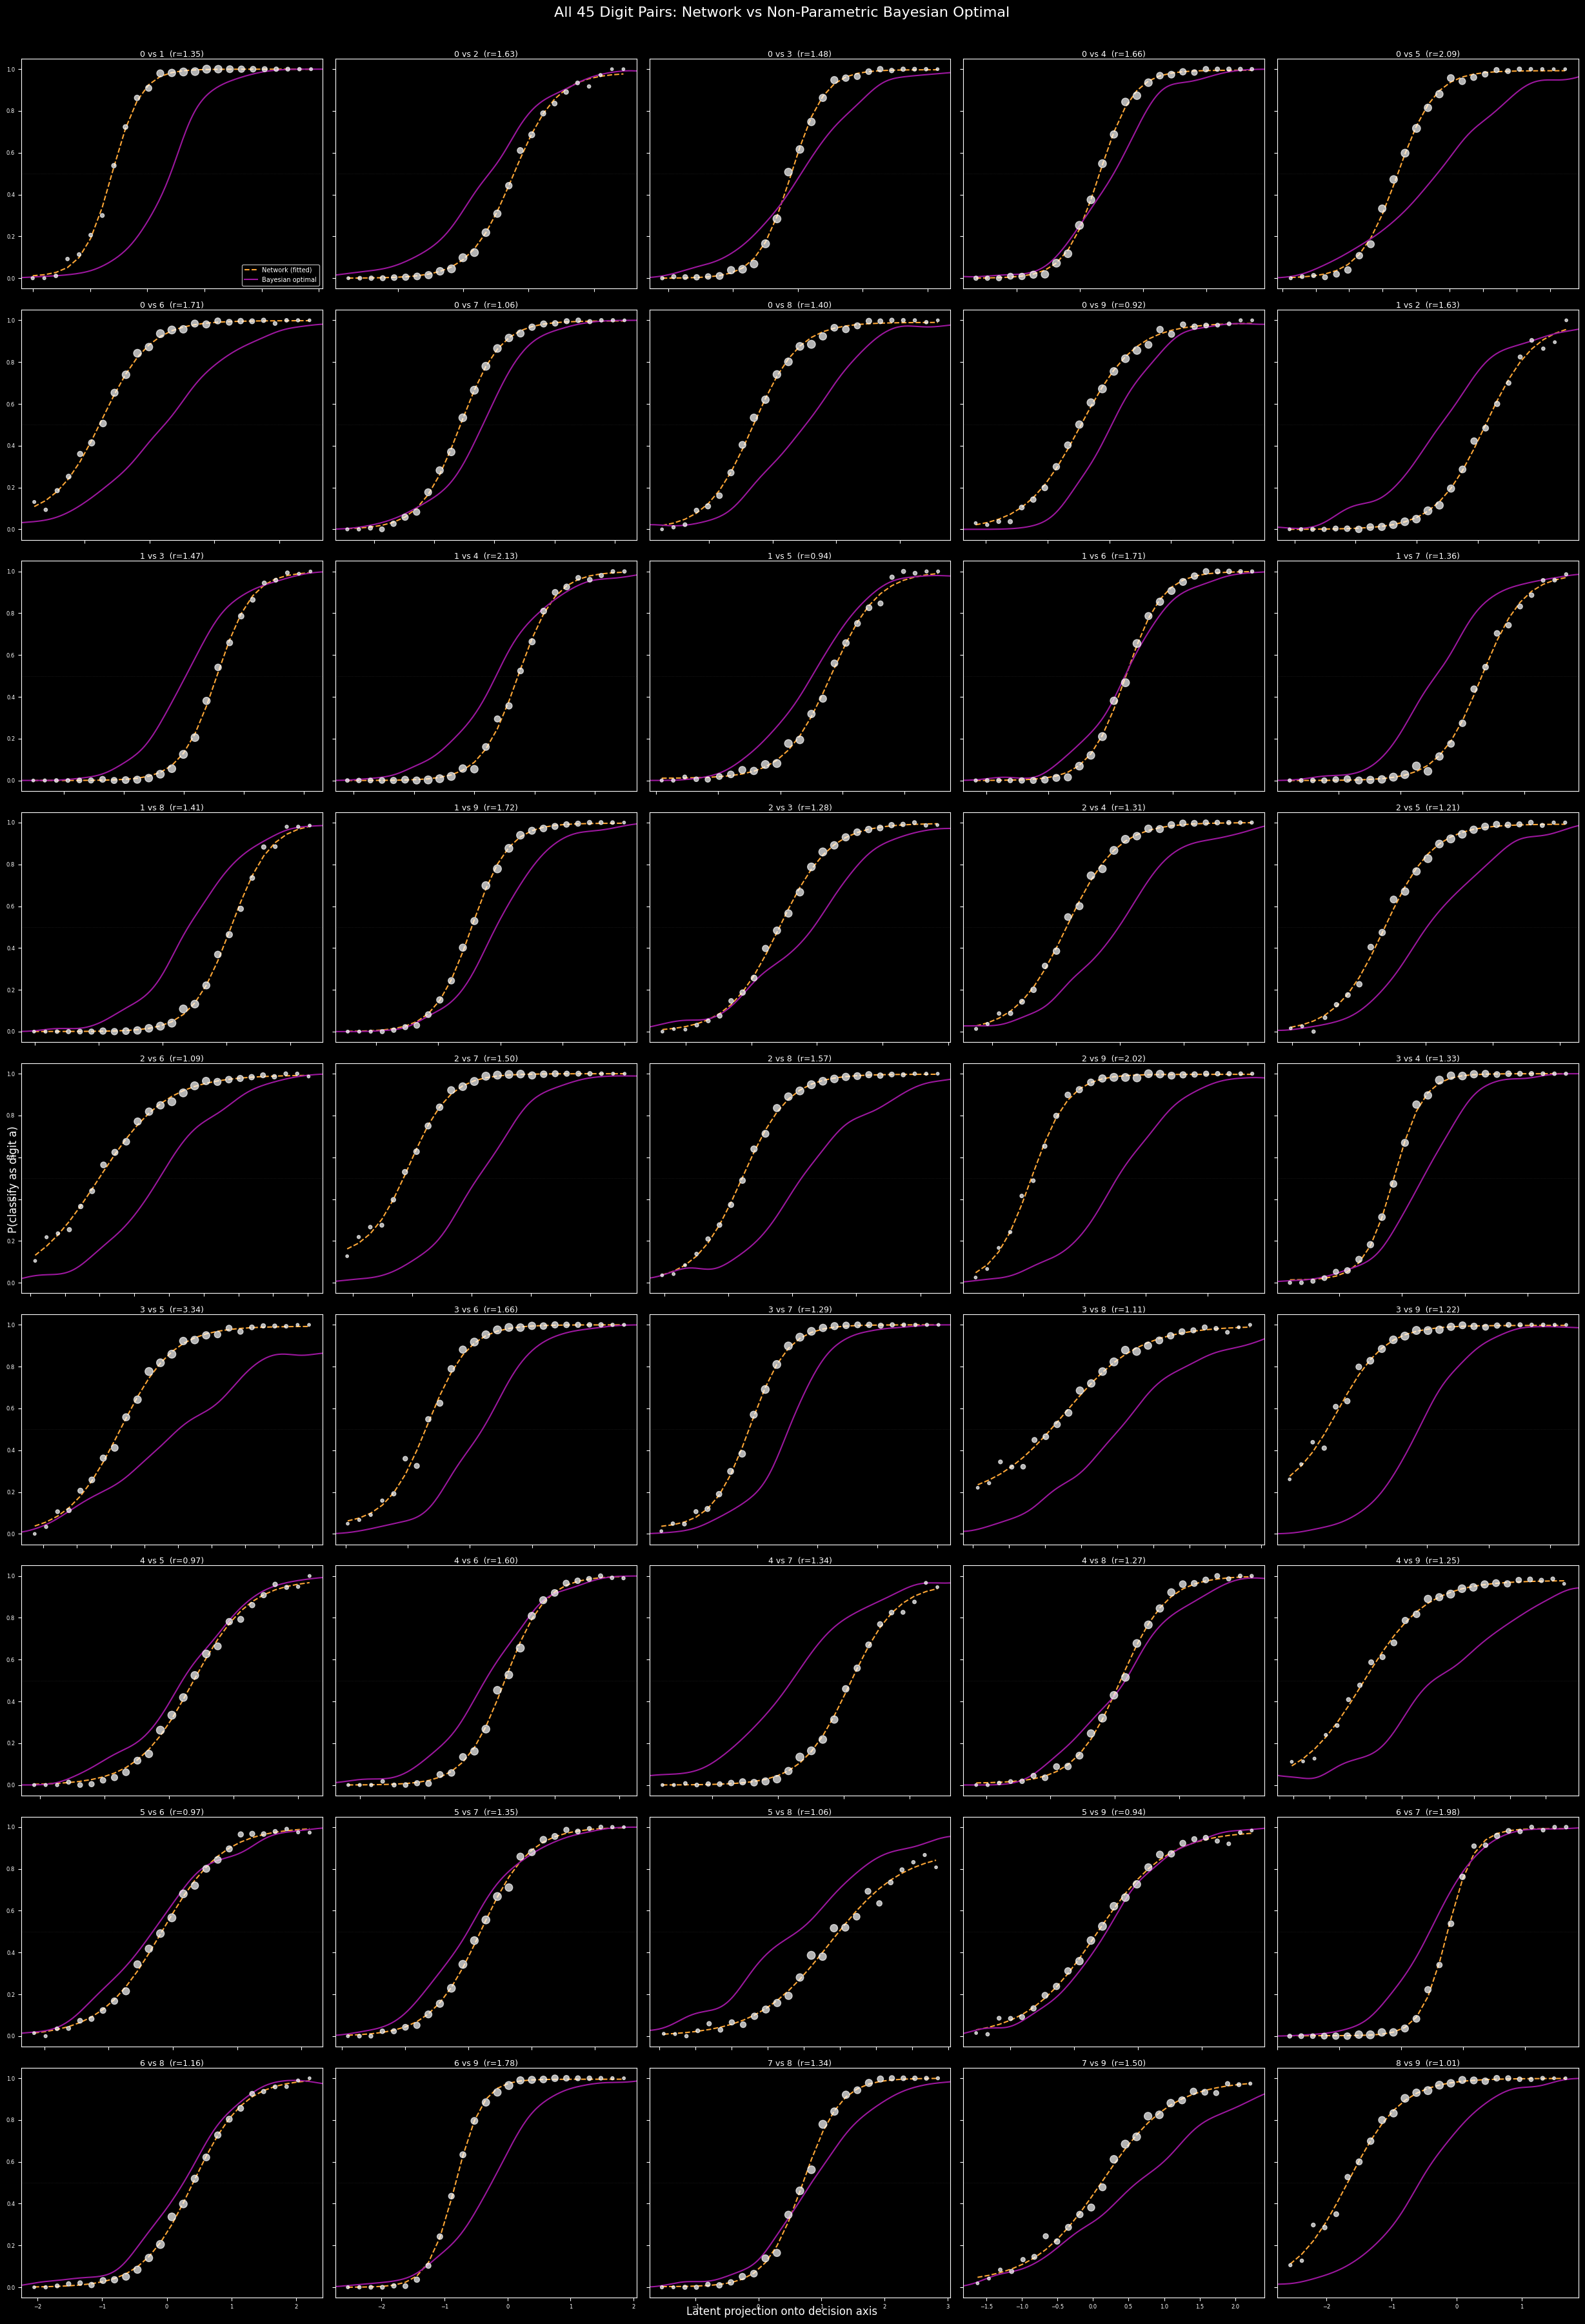

In [23]:
# 45-pair sigmoid mosaic: network vs non-parametric Bayesian optimal
if df_np is not None and curves_data is not None:
    fig = plot_all_pairs_sigmoid_mosaic(curves_data, df_np)
    save_figure(fig, "03_np_sigmoid_mosaic")
    plt.show()
else:
    print("Run: python scripts/run_all_pairs_bayesian.py")

### Non-Parametric Bayesian Summary
- **NP slope ratio heatmap**: network slope / Bayesian slope at midpoint (1.0 = perfectly calibrated)
- **Midpoint calibration**: fitted midpoint vs Bayesian-optimal midpoint (identity line = perfect)
- **Midpoint error heatmap**: signed difference (network - Bayesian)
- **Slope ratio distribution**: histogram showing how tightly clustered the slope ratios are

Saved: ./output\03_np_bayesian_summary.png


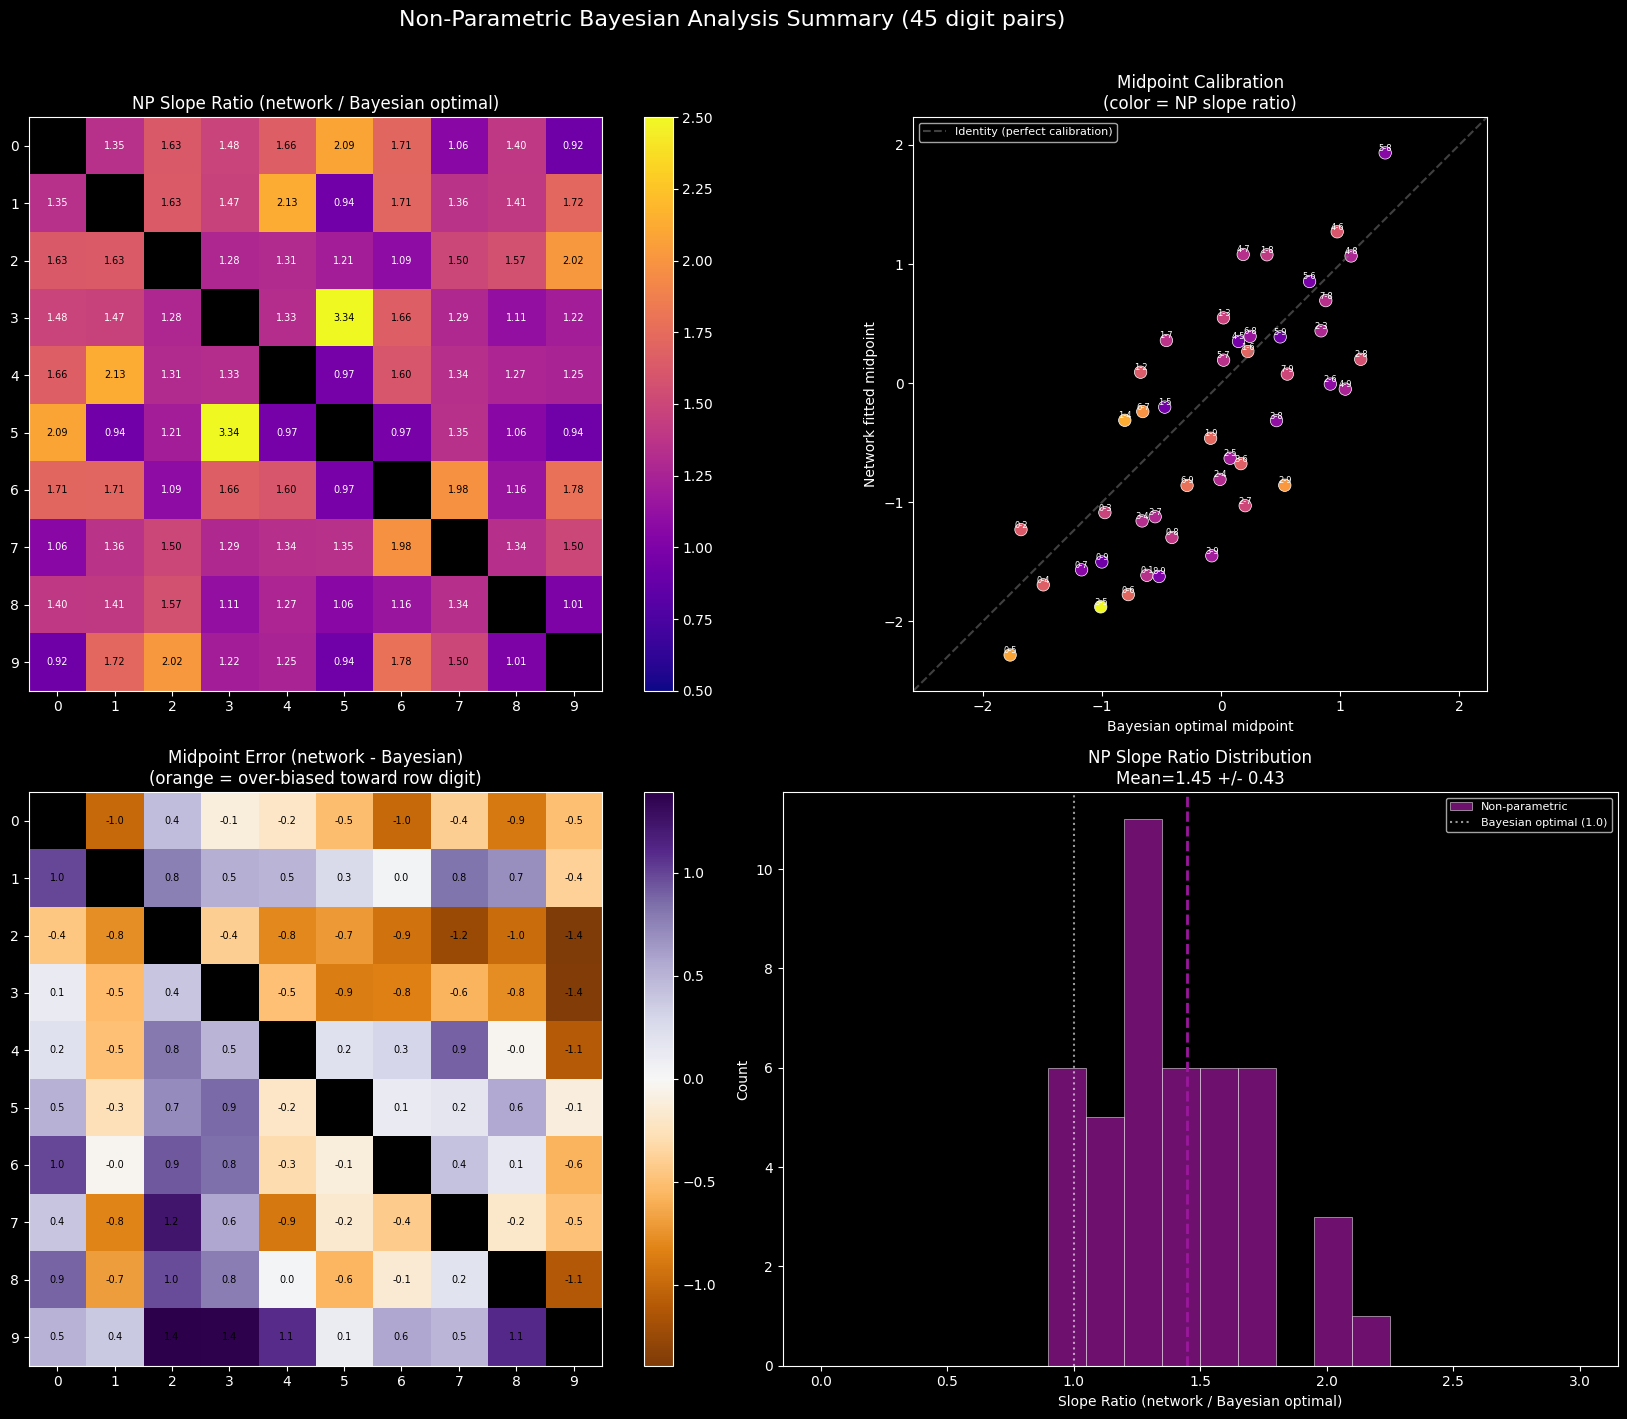

In [24]:
# Non-parametric Bayesian summary: slope ratio, midpoint calibration, distributions
if df_np is not None:
    fig = plot_np_bayesian_summary(df_np)
    save_figure(fig, "03_np_bayesian_summary")
    plt.show()
else:
    print("Run: python scripts/run_all_pairs_bayesian.py")

### Average Sigmoid: Network vs Non-Parametric Bayesian
Average curves across all 45 pairs (centered at each pair's own midpoint),
with shaded ±1 std regions. The non-parametric Bayesian reference uses only
unperturbed visual geometry + training prior — no network parameters.

Saved: ./output\03_np_average_sigmoid.png


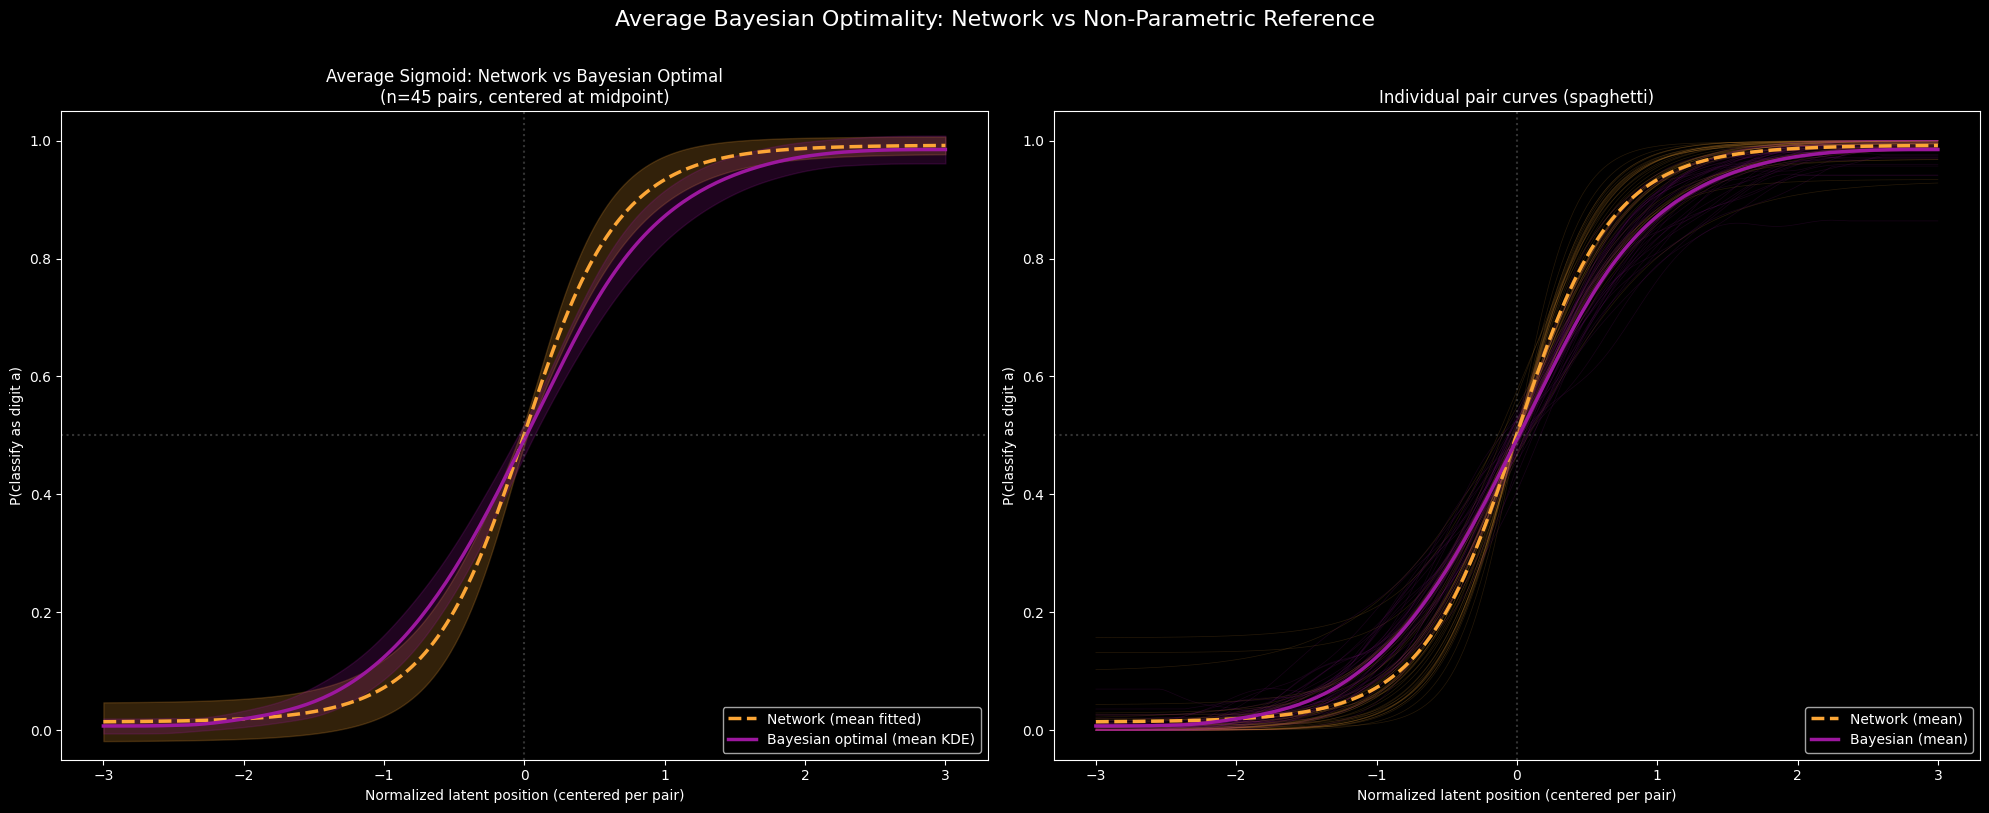


NON-PARAMETRIC BAYESIAN ANALYSIS SUMMARY

Slope ratio (network / Bayesian optimal): 1.448 +/- 0.426
  -> Network is OVER-CONFIDENT relative to Bayesian optimal
     (steeper transitions than warranted by visual geometry + prior)

Midpoint calibration:
  Mean error: -0.290
  Mean |error|: 0.595
  -> Systematic midpoint miscalibration


In [25]:
# Average sigmoid comparison: network vs non-parametric Bayesian optimal
if df_np is not None and curves_data is not None:
    fig = plot_average_sigmoid_v2(curves_data, df_np)
    save_figure(fig, "03_np_average_sigmoid")
    plt.show()

    # Print interpretation
    valid_np = df_np.dropna(subset=['np_slope_ratio'])
    mean_sr = valid_np['np_slope_ratio'].mean()
    std_sr = valid_np['np_slope_ratio'].std()
    valid_me = df_np.dropna(subset=['np_midpoint_error'])
    mean_me = valid_me['np_midpoint_error'].mean()
    mean_abs_me = valid_me['np_midpoint_error'].abs().mean()

    print(f"\n{'='*70}")
    print(f"NON-PARAMETRIC BAYESIAN ANALYSIS SUMMARY")
    print(f"{'='*70}")
    print(f"\nSlope ratio (network / Bayesian optimal): {mean_sr:.3f} +/- {std_sr:.3f}")
    if mean_sr > 1.2:
        print(f"  -> Network is OVER-CONFIDENT relative to Bayesian optimal")
        print(f"     (steeper transitions than warranted by visual geometry + prior)")
    elif mean_sr > 0.8:
        print(f"  -> Network is WELL-CALIBRATED to Bayesian optimal")
    else:
        print(f"  -> Network is UNDER-CONFIDENT relative to Bayesian optimal")
    print(f"\nMidpoint calibration:")
    print(f"  Mean error: {mean_me:+.3f}")
    print(f"  Mean |error|: {mean_abs_me:.3f}")
    if mean_abs_me < 0.5:
        print(f"  -> Good midpoint calibration (errors < 0.5 on average)")
    else:
        print(f"  -> Systematic midpoint miscalibration")
    print(f"{'='*70}")
else:
    print("Run: python scripts/run_all_pairs_bayesian.py")